In [1]:
!pip install pypdf

In [ ]:
import pypdf.

In [3]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("data/Samsung_Card_Manual_Korean_1.3.pdf")
pages = loader.load()  # List[Document] 형태로 반환


In [4]:
pages

[Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2019-01-02T09:40:06+09:00', 'author': 'master', 'moddate': '2019-01-02T09:40:06+09:00', 'source': 'data/Samsung_Card_Manual_Korean_1.3.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}, page_content='사용설명서           SAMSUNG PROPRIETARY \nRevision1.3 \n1 \n \n \n \n \n \n \n \n \n \n \n \n \n \n. \n \n법적 고지 사항 \n삼성 전자는 통지 없이 제품, 정보 및 사양을 변경할 권리를 보유합니다.  \n여기에 언급된 제품 및 사양은 참조용으로만 사용되며, 여기에 언급된 모든 정보는 공지 없이 변경될 수 있고 \n어떠한 종류의 보증도 없이 "있는 그대로" 제공됩니다. 본 문서 및 여기에 명시된 모든 정보는 삼성 전자의 \n유일하고 배타적인 자산으로 보유됩니다. 본 문서에 따라 어떠한 특허권, 저작권, 마스크워크, 상표 또는 기타 \n지적 재산권도 묵시적, 금반언적 또는 기타 어떤 방식으로도 한 당사자가 다른 당사자에게 부여할 수 없습니다. \n삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적 \n상해를 야기할 수 있는 유사 제품, 군용 또는 방어 기기 또는 특정 계약/조항이 적용될 수 있는 정부의 조달에 \n사용할 의도로 설계되지 않았습니다. 삼성 제품에 관한 업데이트 또는 추가 정보는 가까운 삼성 대리점에 \n문의하십시오. 모든 브랜드 이름, 상표 및 등록 상표는 해당 소유권자가 소유합니다.  \nCopyright, 2019 Samsung Electronics Co., L

In [5]:
len(pages)

6

In [6]:
pages[0].page_content[:500]

'사용설명서           SAMSUNG PROPRIETARY \nRevision1.3 \n1 \n \n \n \n \n \n \n \n \n \n \n \n \n \n. \n \n법적 고지 사항 \n삼성 전자는 통지 없이 제품, 정보 및 사양을 변경할 권리를 보유합니다.  \n여기에 언급된 제품 및 사양은 참조용으로만 사용되며, 여기에 언급된 모든 정보는 공지 없이 변경될 수 있고 \n어떠한 종류의 보증도 없이 "있는 그대로" 제공됩니다. 본 문서 및 여기에 명시된 모든 정보는 삼성 전자의 \n유일하고 배타적인 자산으로 보유됩니다. 본 문서에 따라 어떠한 특허권, 저작권, 마스크워크, 상표 또는 기타 \n지적 재산권도 묵시적, 금반언적 또는 기타 어떤 방식으로도 한 당사자가 다른 당사자에게 부여할 수 없습니다. \n삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적 \n상해를 야기할 수 있는 유사 제품, 군용 또는 방어 기기 또는 특정 계약/조항이 적용될 수 있'

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [14]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

In [13]:
docs = splitter.split_documents(pages)

In [15]:
docs[1].page_content[:500]

'사용설명서           SAMSUNG PROPRIETARY \nRevision1.3 \n2 \n \n \n삼성 메모리 카드/UFD 인증 유틸리티 \n \n삼성 메모리 카드/UFD 인증 유틸리티를 통해 정식 삼성 제품인지 여부를 확인할 수 있습니다. \n하기 제품에 한해 본 유틸리티로 인증이 가능합니다.  \n- 메모리 카드의 경우 V 표시(  )가 있는 제품에 한하여 사용 가능합니다. \n- UFD 제품(Bar Plus)의 경우 제품 포장에 V표시와 함께‘인증 가능(Authentication Available)’ \n라는 문구가 적혀 있습니다.  \n \n \n사용 방법 안내 \n1. 본 유틸리티는 한국어, 영어, 중국어를 지원합니다. 기본으로 선택되는 언어는 \n영어입니다. 유틸리티 처음 실행 시 "최종 사용자 라이선스 계약"(EULA)이 표시되며, \n계속 진행하려면 EULA에 동의해야 합니다. 한 번 동의하면 이후에는 EULA가 표시되지 \n않습니다.'

In [17]:
# Vector DB인 FAISS DB를 설치합니다.
!pip install faiss-cpu --no-cache-dir


In [23]:
import os
import requests
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv()

# API 키 가져오기
api_key = os.environ.get("API_KEY")

In [24]:
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings()

In [21]:
from langchain_community.vectorstores import FAISS


In [25]:
vectordb = FAISS.from_documents(docs, embeddings)

In [26]:
vectordb

# 검색

In [29]:
retriever = vectordb.as_retriever(search_kwargs={"k": 3})

In [38]:
msg = """
너는 삼성전자 메모리카드 매뉴얼에 대한 전문 어시스턴트이다.
다음의 참고 문서를 바탕으로 질문에 정확하게 답하라.

[참고문서]
{context}

[질문]
{question}

한글로 간결하고 정확하게 답변하라."""

In [39]:
prompt = ChatPromptTemplate.from_template(msg)

In [40]:
llm=ChatOpenAI(model="gpt-4o-mini")

In [41]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)
query = "이 유틸리티는 동시에 몇 개의 메모리카드나 UFD를 인식할 수 있나?"  # 예시 질의
answer = rag_chain.invoke(query)

In [42]:
answer

'이 유틸리티는 최대 8개의 메모리 카드 또는 UFD를 동시에 인식할 수 있습니다.'

In [43]:
llm.invoke(query).content

'일반적으로 메모리 카드나 USB 플래시 드라이브(UFD)를 인식할 수 있는 개수는 사용 중인 유틸리티의 종류와 시스템의 하드웨어적 제약에 따라 다릅니다. 일반적인 컴퓨터 시스템에서는 USB 포트를 통해 여러 개의 UFD를 연결할 수 있으며, 포트의 수에 따라 동시 인식 가능한 개수가 달라질 수 있습니다.\n\n예를 들어, USB 허브를 사용하면 여러 개의 UFD를 동시에 연결할 수 있고, 메모리 카드 리더기는 여러 슬롯이 있는 경우 여러 카드도 동시에 인식할 수 있습니다. 하지만 한 번에 너무 많은 장치를 연결하면 데이터 전송 속도가 저하될 수 있습니다.\n\n따라서 구체적인 유틸리티와 사용 환경에 따라 다르므로, 해당 유틸리티의 설명서를 참조하거나 제조사에 문의하는 것이 좋습니다.'

# 질문3개 llm vs rag

In [44]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. 모델 및 파서 설정
llm = ChatOpenAI(model="gpt-4o")
parser = StrOutputParser()

# 2. 프롬프트 템플릿 설정
# LLM 단독 모드
pure_prompt = ChatPromptTemplate.from_template("{question}")

# RAG 모드 (외부 지식을 context로 주입)
rag_prompt = ChatPromptTemplate.from_template(msg)

# 3. 테스트 질문 리스트
questions = [
    "삼성전자가 가장 최근에 양산을 시작한 HBM 제품의 명칭과 사양은?",
    "2024년 4분기 삼성전자 메모리 사업부의 매출액은?",
    "DRAM과 낸드 플래시의 기술적 차이점은?"
]

# 4. 가상의 검색 데이터 (RAG용 외부 지식)
# 실제 프로젝트에서는 여기서 웹 크롤링이나 PDF 검색 결과가 들어갑니다.
mock_context = """
삼성전자는 2024년 말 업계 최초로 HBM3E 12단 양산을 시작했으며, 
2024년 4분기 메모리 사업부 매출은 전년 대비 00% 성장한 00조 원을 기록했습니다.
"""

# 5. 실행 비교
print("=== LLM vs RAG 비교 테스트 ===\n")

for i, q in enumerate(questions):
    print(f"질문 {i+1}: {q}")
    
    # LLM 단독 실행
    pure_chain = pure_prompt | llm | parser
    print(f"[LLM 답변]: {pure_chain.invoke({'question': q})[:100]}...") 
    
    # RAG 방식 실행
    rag_chain = rag_prompt | llm | parser
    print(f"[RAG 답변]: {rag_chain.invoke({'question': q, 'context': mock_context})}")
    
    print("-" * 50)

=== LLM vs RAG 비교 테스트 ===

질문 1: 삼성전자가 가장 최근에 양산을 시작한 HBM 제품의 명칭과 사양은?
[LLM 답변]: 삼성전자가 최근 양산을 시작한 HBM(High Bandwidth Memory) 제품은 "HBM3"입니다. HBM3는 이전 세대에 비해 성능과 용량이 크게 향상되었습니다. 기본적인 ...
[RAG 답변]: 삼성전자가 가장 최근에 양산을 시작한 HBM 제품의 명칭은 HBM3E입니다. 구체적인 사양은 12단입니다.
--------------------------------------------------
질문 2: 2024년 4분기 삼성전자 메모리 사업부의 매출액은?
[LLM 답변]: 죄송하지만, 2024년 4분기 삼성전자 메모리 사업부의 매출액에 대한 정보는 현재 알 수 없습니다. 미래의 특정 재무 성과에 대한 정보는 기업의 공식 발표 전까지 공개되지 않으며,...
[RAG 답변]: 죄송합니다. 주어진 정보에서는 2024년 4분기 삼성전자 메모리 사업부의 정확한 매출액을 알 수 없습니다.
--------------------------------------------------
질문 3: DRAM과 낸드 플래시의 기술적 차이점은?
[LLM 답변]: DRAM(Dynamic Random-Access Memory)와 낸드 플래시 메모리는 모두 비휘발성 메모리 장치로 사용되지만, 그들의 기술적 차이점은 여러 가지가 있습니다.

1....
[RAG 답변]: DRAM은 데이터를 저장하기 위해 전기가 필요한 휘발성 메모리로, 빠른 속도와 낮은 지연 시간을 제공합니다. 반면, 낸드 플래시는 전원이 없어도 데이터를 유지할 수 있는 비휘발성 메모리로, 높은 데이터 저장 밀도와 가격 경쟁력이 특징입니다.
--------------------------------------------------


In [52]:
from dotenv import load_dotenv
import os
load_dotenv()

from pinecone import Pinecone

pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])


In [47]:
!pip install pinecone

In [48]:
index_name = "developer-quickstart-py"

if not pc.has_index(index_name):
    pc.create_index_for_model(
        name=index_name,
        cloud="aws",
        region="us-east-1",
        embed={
            "model":"llama-text-embed-v2",
            "field_map":{"text": "chunk_text"}
        }
    )

In [55]:
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])

# 인덱스 생성
pc.create_index(
    name="embedding-3d",        # 인덱스 이름
    dimension=3,                # 벡터 차원 (반드시 맞춰야 함)
    metric="cosine",            # 유사도 측정 방식
    spec=ServerlessSpec(
        cloud="aws",            # 클라우드
        region="us-east-1"      # 리전
    )
)

index = pc.Index("embedding-3d")
index.describe_index_stats()

for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)

c:\Users\Admin\miniconda3\envs\langchain_rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [56]:
# 벡터를 인덱스에 업서트(upsert)합니다.
# "embedding-3d-ns1" 네임스페이스에 벡터를 추가합니다.
index.upsert(
    vectors=[
        {
            "id": "vec1",
            "values": [1.0, 1.5, 2.0],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec2",
            "values": [2.0, 1.0, 0.5],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec3",
            "values": [0.1, 0.3, 0.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec4",
            "values": [1.0, 2.5, 3.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec5",
            "values": [3.0, 1.2, 1.3],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec6", 
            "values": [0.3, 1.1, 2.5],  #    vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }
    ],
    namespace="embedding-3d-ns1"
)

{'upserted_count': 6}

In [58]:
index.describe_index_stats()


{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'embedding-3d-ns1': {'vector_count': 6}},
 'total_vector_count': 6,
 'vector_type': 'dense'}

In [60]:
# embedding-3d-ns1 네임스페이스의 모든 레코드 id를 조회합니다.
for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)
    

['vec1', 'vec2', 'vec3', 'vec4', 'vec5', 'vec6']


In [64]:
response = index.query(
    namespace="embedding-3d-ns1",
    vector=[0.2, 0.6, 0.7],
    top_k=3,
    include_values=True,
    include_metadata=True
)

print(response)

{'matches': [{'id': 'vec4',
              'metadata': {'genre': 'action'},
              'score': 0.996175408,
              'values': [1.0, 2.5, 3.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.986291051,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec1',
              'metadata': {'genre': 'drama'},
              'score': 0.98464644,
              'values': [1.0, 1.5, 2.0]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


In [62]:
response = index.query(
    namespace="embedding-3d-ns1",
    vector=[0.1, 0.3, 0.7],
    top_k=3,
    include_values=True,
    include_metadata=True,
    filter={
        "genre": {"$eq": "drama"}
    }
)

print(response)

{'matches': [{'id': 'vec6',
              'metadata': {'genre': 'drama'},
              'score': 1.00006485,
              'values': [0.3, 1.1, 2.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.990785182,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec1',
              'metadata': {'genre': 'drama'},
              'score': 0.943127871,
              'values': [1.0, 1.5, 2.0]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


NameError: name 'values' is not defined

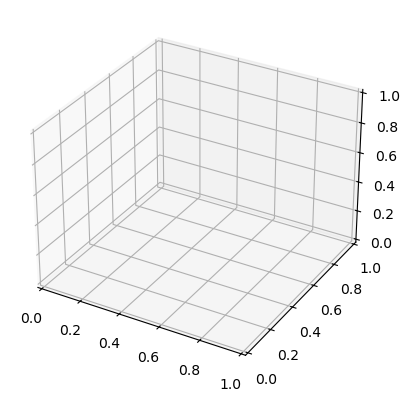

In [63]:
import matplotlib.pyplot as plt

# 3D 플롯을 생성합니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 각 벡터의 ID와 값을 사용하여 3D 공간에 점을 그립니다.
for i, id in enumerate(ids):
    if id == "qv":
        # 쿼리 벡터는 노란색 사각형으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id, color='y', s=50, marker='s')
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)
    else:
        # 나머지 벡터는 기본 색상으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id)
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)

# 축 레이블과 제목을 설정합니다.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Embedding Vector Space')

# 플롯을 표시합니다.
plt.show()

In [65]:
# Pinecone 인덱스를 생성합니다.
# 인덱스 이름은 "wiki"이고, 차원은 1536, 메트릭은 코사인 유사도를 사용합니다.
# 인덱스는 AWS의 us-east-1 리전에서 서버리스 사양으로 생성됩니다.
index_name = "wiki"

pc.create_index(
    name=index_name,
    dimension=1536,  # 모델 차원
    metric="cosine",  # 모델 메트릭
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

{
    "name": "wiki",
    "metric": "cosine",
    "host": "wiki-fzil9x1.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 1536,
    "deletion_protection": "disabled",
    "tags": null
}

In [66]:
# 'wiki' 인덱스를 가져옵니다.
index = pc.Index(index_name)

# 인덱스의 통계 정보를 설명합니다.
index.describe_index_stats()

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

In [67]:
from datasets import load_dataset

# 예: 2023-11-01 덤프의 한국어(ko) 전체 학습 split, # 언어/스냅샷 선택
data = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train[:100]")
print(data)
print(data[0])  # {'id', 'url', 'title', 'text', 'timestamp' ... 형식}


c:\Users\Admin\miniconda3\envs\langchain_rag_env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\datasets--wikimedia--wikipedia. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 647897/647897 [00:10<00:00, 63905.34 examples/s] 


Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 100
})
{'id': '5', 'url': 'https://ko.wikipedia.org/wiki/%EC%A7%80%EB%AF%B8%20%EC%B9%B4%ED%84%B0', 'title': '지미 카터', 'text': '제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.\n\n생애\n\n어린 시절 \n지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.\n\n조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.\n\n정계 입문 \n1962년 조지아주 상원 의원 선거에서 낙선하였으나, 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주지사 선거에 낙선하지만, 1970년 조지아 주지사 선거에서 당선됐다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.\n\n대통령 재임 \n\n1976년 미합중국 제39대 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워서, 많은 지지를 받았는데 제럴드 포드 대통령을 누르고 당선되었다.\n\n카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.\n\n외교 정책 \n카터는 이집트와 이스라엘을 조정하여 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다. 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 그러나 1979년, 양국 간의 평화조약이 백악관에서 이루어졌다.\n\n소련과 제2차 전략 무기 제한 

In [71]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# RecursiveCharacterTextSplitter를 초기화합니다.
# 이 클래스는 텍스트를 재귀적으로 문자 단위로 분할합니다.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,  # 분할할 텍스트의 크기
    #chunk_size=1000,  # 분할할 텍스트의 크기
    #chunk_size=2048,  # 분할할 텍스트의 크기
    #chunk_overlap=100,  # 분할된 텍스트의 중첩 크기
    chunk_overlap=20,  # 분할된 텍스트의 중첩 크기
    length_function=len,  # 텍스트 길이를 계산하는 함수
    separators=["\n\n", "\n", " ", ""]  # 분할할 텍스트의 구분자
)

splitter

In [109]:
embedding_model  = OpenAIEmbeddings(model="text-embedding-3-small")

In [111]:
from langchain_openai import OpenAIEmbeddings
from tqdm.auto import tqdm
from uuid import uuid4
import time
batch_size = 20  #한 번에 올린 upsert 요청 바디가 3MB, Pinecone 서버의 2MB 제한을 넘으면 오류 > 배치사이즈 작게 하기
texts = []
metas = []
count = 0
for i, sample in enumerate(tqdm(data)):

    full_text = sample["text"] # Wikipedia 문서 텍스트
    metadata = {
        'wiki_id': str(sample["id"]),  # Wikipedia 문서 ID
        'url': sample["url"],  # Wikipedia 문서 URL
        'title': sample["title"],  # Wikipedia 문서 제목
    }

        # 텍스트를 청크로 분할합니다.
    chunks = splitter.split_text(full_text)  # 텍스트를 청크로 분할합니다.
    print(len(chunks))

    # 각 청크에 대해 반복합니다.
    for i, chunk in enumerate(chunks):
        chunk_text = f"제목: {sample['title']}\n\n{chunk}"
        record = {
            'chunk_id': i,  # 청크 ID
            'text': chunk_text,
            #'full_text': full_text,  # 전체 텍스트
            **metadata,  # 메타데이터 언패킹
        }

        texts.append(chunk_text)  # 청크를 텍스트 목록에 추가합니다.
        metas.append(record)  # 메타데이터를 메타데이터 목록에 추가합니다.

        count += 1  # 처리된 청크 수를 증가시킵니다.

        # batch_size만큼의 청크를 처리할 때마다 청크를 Pinecone 인덱스에 추가합니다.
        if count % batch_size == 0:
            # Pinecone 인덱스에 청크를 추가합니다.
            ids = [str(uuid4()) for _ in range(len(texts))]
            batch_embeddings = embedding_model.embed_documents(texts)
            index.upsert(
                vectors=zip(ids, batch_embeddings, metas),
                namespace="wiki-ns3")
            # 청크 목록과 메타데이터 목록을 비웁니다.
            texts = []
            metas = []
            # 1초 대기합니다.
            time.sleep(1)

if texts:
    ids = [str(uuid4()) for _ in range(len(texts))]
    batch_embeddings = embedding_model.embed_documents(texts)
    index.upsert(
        vectors=zip(ids, batch_embeddings, metas),
        namespace="wiki-ns3",
    )

  0%|          | 0/100 [00:00<?, ?it/s]

13
21


  2%|▏         | 2/100 [00:04<03:25,  2.10s/it]

3
11


  4%|▍         | 4/100 [00:07<02:57,  1.84s/it]

...

 97%|█████████▋| 97/100 [04:43<00:08,  2.71s/it]

4
139


 99%|█████████▉| 99/100 [05:09<00:05,  5.60s/it]

38


100%|██████████| 100/100 [05:18<00:00,  3.18s/it]


In [77]:
from langchain_pinecone import PineconeVectorStore

In [112]:
vectorstore = PineconeVectorStore.from_existing_index(
    index_name="wiki",
    namespace="wiki-ns1",
    embedding=embedding,
    text_key="title"
)

In [113]:
results = vectorstore.similarity_search(
    query="대한민국의 수도는??",
    namespace="wiki-ns1",
    k=3
)

print(f"검색 결과: {len(results)}")
for i, res in enumerate(results, 1):
    print(f"--- 검색 결과 {i} ---")
    print(res.page_content)
    print(res.metadata)


검색 결과: 3
--- 검색 결과 1 ---
나라 이름순 수도 목록
{'chunk_id': 10.0, 'url': 'https://ko.wikipedia.org/wiki/%EB%82%98%EB%9D%BC%20%EC%9D%B4%EB%A6%84%EC%88%9C%20%EC%88%98%EB%8F%84%20%EB%AA%A9%EB%A1%9D', 'wiki_id': '79'}
--- 검색 결과 2 ---
노무현
{'chunk_id': 88.0, 'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84', 'wiki_id': '85'}
--- 검색 결과 3 ---
노무현
{'chunk_id': 8.0, 'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84', 'wiki_id': '85'}


In [93]:
query_emb = embedding.embed_query("탈모")

raw = index.query(
    vector=query_emb,
    top_k=3,
    namespace="wiki-ns1",
    include_metadata=True
)

print(raw)

{'matches': [{'id': '52e2ed36-682c-4009-8d2f-5e56a2e6fc32',
              'metadata': {'chunk_id': 5.0,
                           'title': '나라 목록',
                           'url': 'https://ko.wikipedia.org/wiki/%EB%82%98%EB%9D%BC%20%EB%AA%A9%EB%A1%9D',
                           'wiki_id': '20'},
              'score': 0.401619554,
              'values': []},
             {'id': '164f5af8-b90e-4ac9-949f-59d4edd82ab6',
              'metadata': {'chunk_id': 19.0,
                           'title': '2002년',
                           'url': 'https://ko.wikipedia.org/wiki/2002%EB%85%84',
                           'wiki_id': '39'},
              'score': 0.372982591,
              'values': []},
             {'id': 'b2f2210f-0f1c-4bb4-b1a5-48c1430a4c84',
              'metadata': {'chunk_id': 261.0,
                           'title': '노무현',
                           'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84',
                           'wiki_id': '85'},
    